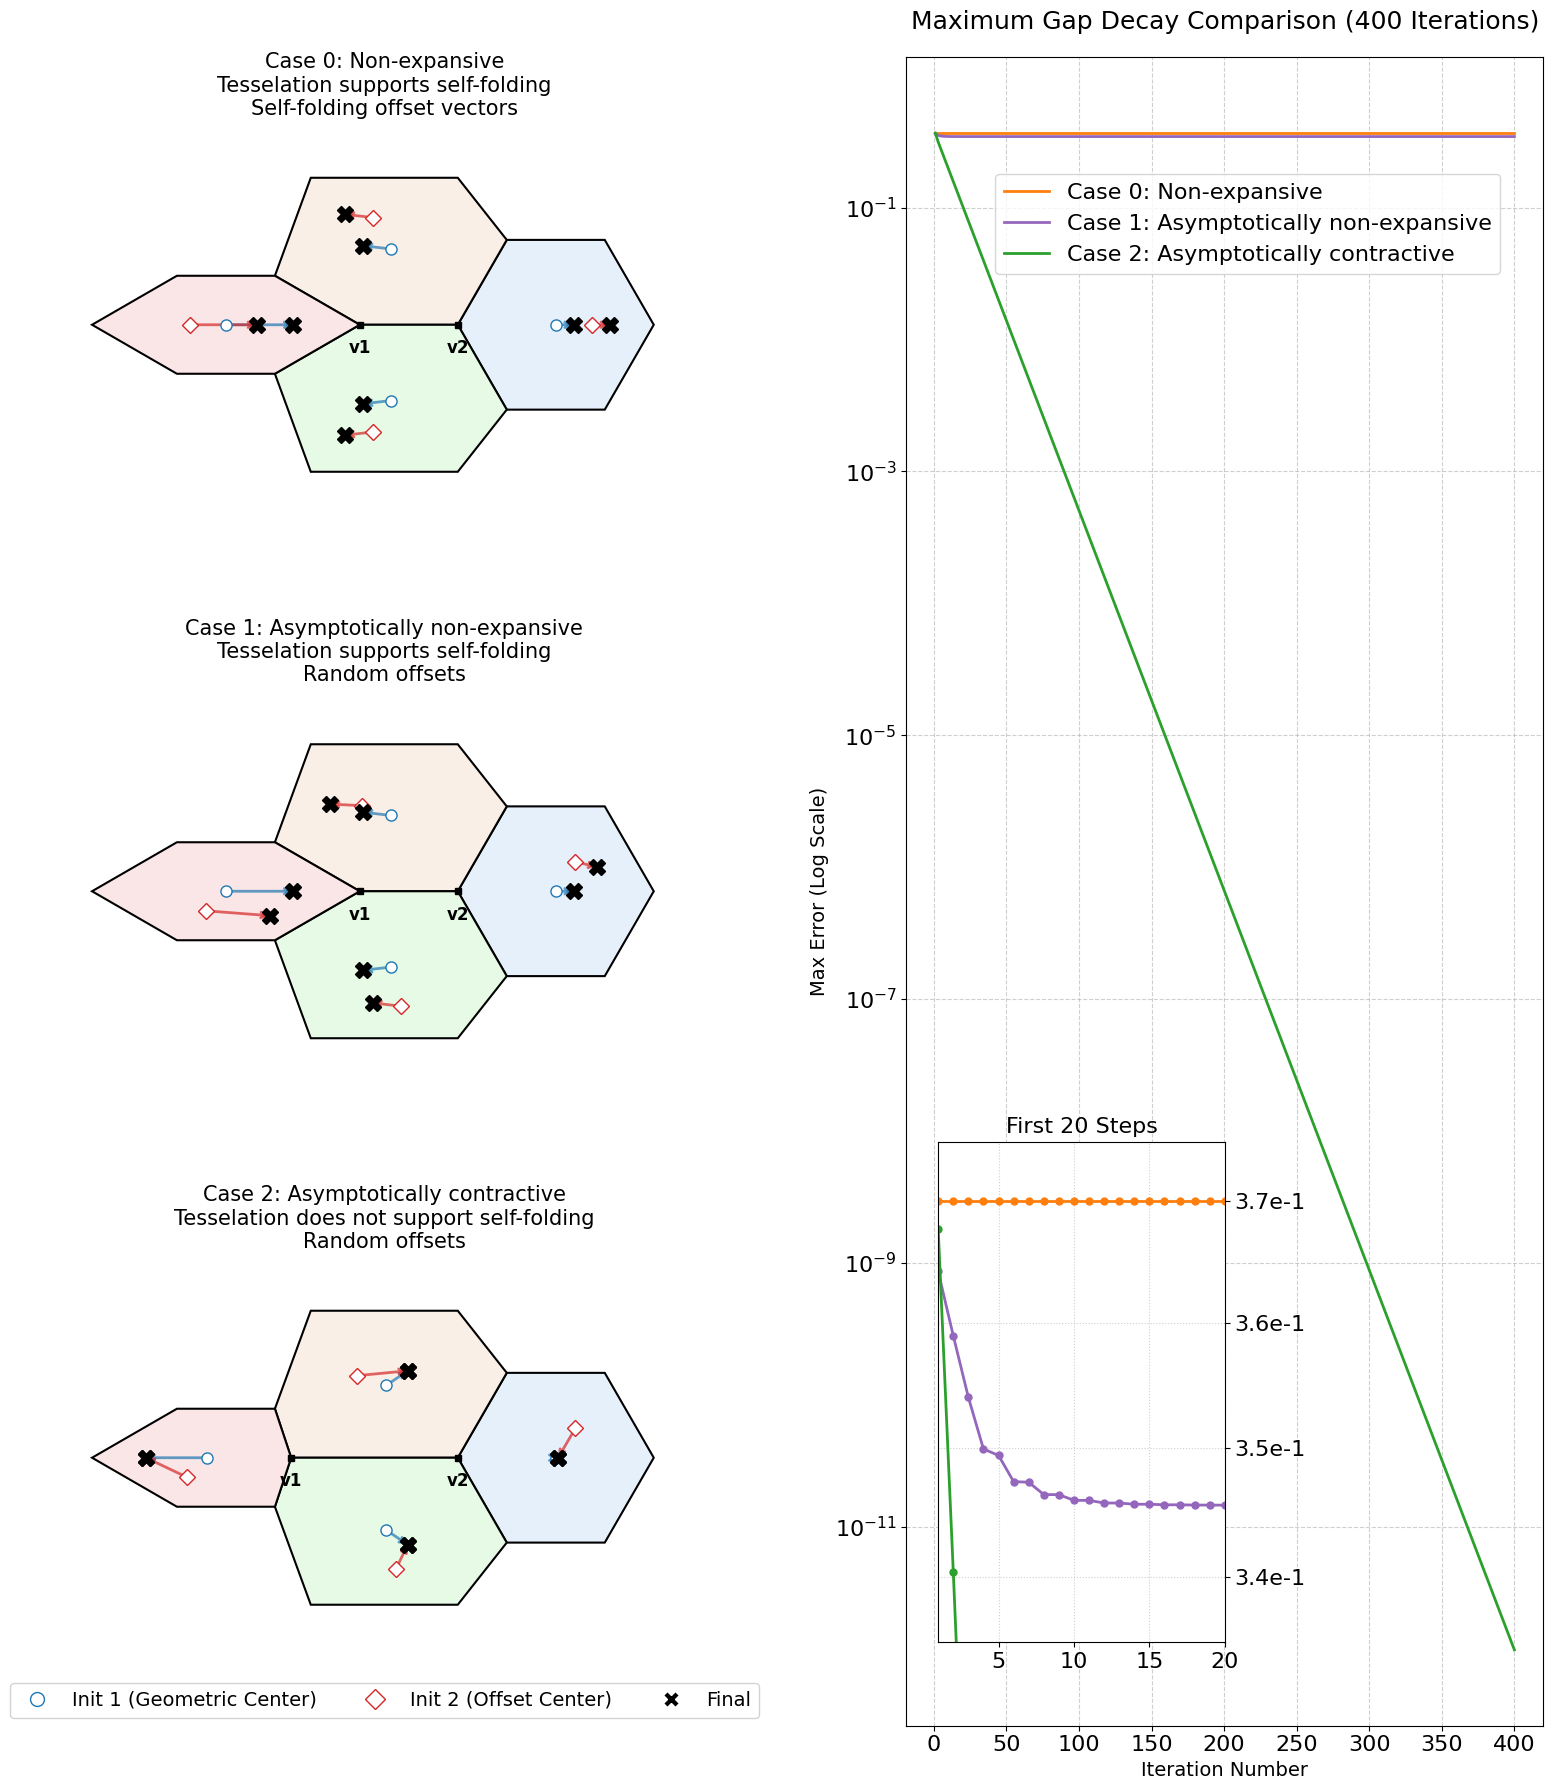

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

# =====================================================================
# 1. Simulation Function
# =====================================================================
def simulate_case(v1_x, offsets):
    # Set up the shared vertices using the parameter for v1
    v1 = (v1_x, 0.0)
    v2 = (1.0, 0.0)
    v3 = (1.5, np.sqrt(3)/2)
    v4 = (1.5, -np.sqrt(3)/2)
    v5 = (-np.sqrt(3)/2, 0.5)
    v6 = (-np.sqrt(3)/2, -0.5)

    # Define the 4 cells.
    cells = {
        'R': {
            'verts': [v2, v4, (2.5, -np.sqrt(3)/2), (3.0, 0.0), (2.5, np.sqrt(3)/2), v3],
            'color': '#e6f0fa', 
        },
        'T': {
            'verts': [v1, v2, v3, (1.0, 1.5), (-0.5, 1.5), v5],
            'color': '#faefe6', 
        },
        'B': {
            'verts': [v1, v6, (-0.5, -1.5), (1.0, -1.5), v4, v2],
            'color': '#e6fae6', 
        },
        'L': {
            'verts': [v1, v5, (-np.sqrt(3)/2 - 1, 0.5), (-np.sqrt(3) - 1, 0.0), (-np.sqrt(3)/2 - 1, -0.5), v6],
            'color': '#fae6e6', 
        }
    }

    def polygon_properties(verts):
        x = np.array([v[0] for v in verts])
        y = np.array([v[1] for v in verts])
        dx = np.diff(np.append(x, x[0]))
        dy = np.diff(np.append(y, y[0]))
        perimeter = np.sum(np.hypot(dx, dy))
        
        cross = x * np.roll(y, -1) - y * np.roll(x, -1)
        area = 0.5 * np.sum(cross)
        cx = np.sum((x + np.roll(x, -1)) * cross) / (6 * area)
        cy = np.sum((y + np.roll(y, -1)) * cross) / (6 * area)
        return perimeter, np.array([cx, cy])

    def reflect_over_line(p, a, b):
        a, b, p = np.array(a), np.array(b), np.array(p)
        v = b - a
        denom = np.dot(v, v)
        if denom == 0: return p
        t = np.dot(p - a, v) / denom
        proj = a + t * v
        return 2 * proj - p

    edges_map = {}
    seeds_1_init = {}
    seeds_2_init = {}
    seeds_1 = {}
    seeds_2 = {}

    # Initialize seeds and map edges
    for name, data in cells.items():
        verts = data['verts']
        perim, centroid = polygon_properties(verts)
        cells[name]['perimeter'] = perim
        
        # Dataset 1: Standard Centroids
        seeds_1_init[name] = centroid.copy()
        seeds_1[name] = centroid.copy()
        
        # Dataset 2: Centroids + offset
        seeds_2_init[name] = centroid.copy() + offsets[name]
        seeds_2[name] = centroid.copy() + offsets[name]
        
        for i in range(len(verts)):
            p1, p2 = verts[i], verts[(i+1) % len(verts)]
            key = tuple(sorted((round(p1[0], 5), round(p1[1], 5), round(p2[0], 5), round(p2[1], 5))))
            if key not in edges_map:
                edges_map[key] = []
            edges_map[key].append({'cell': name, 'p1': p1, 'p2': p2})

    num_iterations = 400
    beta = 1.0
    max_errors = []

    # =====================================================================
    # EXACT ITERATION LOOP AS PROVIDED IN YOUR SNIPPET
    # =====================================================================
    for _ in range(num_iterations):
        new_seeds_1 = {}
        new_seeds_2 = {}
        current_max_error = 0.0
        
        for name in cells.keys():
            wsum = 0.0
            acc1 = np.zeros(2)
            acc2 = np.zeros(2)
            
            for key, shared_by in edges_map.items():
                if len(shared_by) == 2:
                    c1, c2 = shared_by[0], shared_by[1]
                    
                    if c1['cell'] == name or c2['cell'] == name:
                        neighbor_name = c2['cell'] if c1['cell'] == name else c1['cell']
                        
                        p1, p2 = np.array(c1['p1']), np.array(c1['p2'])
                        weight = np.sum((p1 - p2)**2) / (cells[name]['perimeter'] * cells[neighbor_name]['perimeter'])
                        
                        # Reflect seeds for both datasets
                        acc1 += weight * reflect_over_line(seeds_1[neighbor_name], p1, p2)
                        acc2 += weight * reflect_over_line(seeds_2[neighbor_name], p1, p2)
                        wsum += weight
                        
            # Update seeds
            if wsum > 0:
                new_seeds_1[name] = (1 - beta) * seeds_1[name] + beta * (acc1 / wsum)
                new_seeds_2[name] = (1 - beta) * seeds_2[name] + beta * (acc2 / wsum)
            else:
                new_seeds_1[name] = seeds_1[name]
                new_seeds_2[name] = seeds_2[name]
            
            # Calculate error magnitude between the two datasets for this cell
            dist = np.linalg.norm(new_seeds_1[name] - new_seeds_2[name])
            if dist > current_max_error:
                current_max_error = dist
                
        max_errors.append(current_max_error)
        
        # Apply updates for next iteration
        seeds_1 = new_seeds_1
        seeds_2 = new_seeds_2
    # =====================================================================

    return cells, seeds_1_init, seeds_2_init, seeds_1, seeds_2, max_errors, v1, v2

# =====================================================================
# 2. Main Plotting Routine
# =====================================================================
fig = plt.figure(figsize=(16, 18))
gs = fig.add_gridspec(3, 2, width_ratios=[1, 1], height_ratios=[1, 1, 1])

ax_geom0 = fig.add_subplot(gs[0, 0])
ax_geom1 = fig.add_subplot(gs[1, 0])
ax_geom2 = fig.add_subplot(gs[2, 0])
ax_err = fig.add_subplot(gs[:, 1])  

# Position inset at bottom-left
axins = ax_err.inset_axes([0.05, 0.05, 0.45, 0.3])

mag = 0.37
offsets_0 = {
    'R': np.array([mag, 0.0]),
    'L': np.array([-mag, 0.0]),
    'T': np.array([-mag * np.cos(np.pi/3), mag * np.sin(np.pi/3)]),
    'B': np.array([-mag * np.cos(np.pi/3), -mag * np.sin(np.pi/3)])
}

offsets_rand = {
    'R': np.array([0.2, 0.3]),
    'T': np.array([-0.3, 0.1]),
    'B': np.array([0.1, -0.4]),
    'L': np.array([-0.2, -0.2])
}

cases = [
    (0.0,  "Case 0: Non-expansive\nTesselation supports self-folding\nSelf-folding offset vectors", ax_geom0, 'tab:orange', offsets_0),
    (0.0,  "Case 1: Asymptotically non-expansive\nTesselation supports self-folding\nRandom offsets", ax_geom1, 'tab:purple', offsets_rand),
    (-0.7, "Case 2: Asymptotically contractive\nTesselation does not support self-folding\nRandom offsets", ax_geom2, 'tab:green', offsets_rand)
]

for v1_x, title, ax_geom, color, offsets in cases:
    cells, s1_init, s2_init, s1_final, s2_final, max_errs, v1, v2 = simulate_case(v1_x, offsets)
    
    # --- Plot Geometry & Trajectories ---
    for name, data in cells.items():
        poly = Polygon(data['verts'], facecolor=data['color'], edgecolor='black', linewidth=1.5, zorder=1)
        ax_geom.add_patch(poly)

    ax_geom.plot(v1[0], v1[1], marker='s', color='black', markersize=5, zorder=4)
    ax_geom.plot(v2[0], v2[1], marker='s', color='black', markersize=5, zorder=4)
    ax_geom.text(v1[0], v1[1] - 0.15, 'v1', ha='center', va='top', fontsize=12, fontweight='bold')
    ax_geom.text(v2[0], v2[1] - 0.15, 'v2', ha='center', va='top', fontsize=12, fontweight='bold')

    for name in cells.keys():
        init1 = s1_init[name]
        init2 = s2_init[name]
        final1 = s1_final[name] 
        final2 = s2_final[name] 
        
        ax_geom.annotate('', xy=final1, xytext=init1,
                    arrowprops=dict(arrowstyle='->', color='tab:blue', lw=2.0, shrinkA=0, shrinkB=0, alpha=0.7),
                    zorder=2)
        
        ax_geom.annotate('', xy=final2, xytext=init2,
                    arrowprops=dict(arrowstyle='->', color='tab:red', lw=2.0, shrinkA=0, shrinkB=0, alpha=0.7),
                    zorder=2)
        
        ax_geom.plot(init1[0], init1[1], marker='o', markerfacecolor='white', markeredgecolor='tab:blue', markersize=8, zorder=3)
        ax_geom.plot(init2[0], init2[1], marker='D', markerfacecolor='white', markeredgecolor='tab:red', markersize=8, zorder=3)
        
        ax_geom.plot(final1[0], final1[1], marker='X', color='black', markersize=12, zorder=4)
        ax_geom.plot(final2[0], final2[1], marker='X', color='black', markersize=12, zorder=4)

    ax_geom.set_aspect('equal')
    ax_geom.axis('off')
    ax_geom.set_xlim(-3.0, 3.5)
    ax_geom.set_ylim(-2.0, 2.0)
    ax_geom.set_title(title, fontsize=15, pad=10)

    # --- Plot Error Decay ---
    iters = range(1, len(max_errs) + 1)
    ax_err.plot(iters, max_errs, linestyle='-', color=color, linewidth=2, label=title.split('\n')[0])
    axins.plot(iters[:20], max_errs[:20], marker='o', linestyle='-', color=color, linewidth=2, markersize=5)

# Shared Legend for Geometry Plots (moved to bottom of the column)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Init 1 (Geometric Center)', markerfacecolor='w', markeredgecolor='tab:blue', markersize=10),
    Line2D([0], [0], marker='D', color='w', label='Init 2 (Offset Center)', markerfacecolor='w', markeredgecolor='tab:red', markersize=10),
    Line2D([0], [0], marker='X', color='w', label='Final', markerfacecolor='k', markersize=12)
]
ax_geom2.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, framealpha=1.0, edgecolor='lightgrey', fontsize=14)

# RHS Error Plot Styling
ax_err.set_yscale('log')
ax_err.set_xlabel('Iteration Number', fontsize=14)
ax_err.set_ylabel('Max Error (Log Scale)', fontsize=14)
ax_err.set_title("Maximum Gap Decay Comparison (400 Iterations)", fontsize=18, pad=20)
ax_err.grid(True, which="both", linestyle='--', alpha=0.6)
ax_err.legend(fontsize=16, loc='center right', bbox_to_anchor=(0.95, 0.9))

#increase tick label size for better readability
ax_err.tick_params(axis='both', which='major', labelsize=16)

# Inset Styling
axins.set_yscale('log')
axins.set_title("First 20 Steps", fontsize=16)
axins.grid(True, which="major", linestyle=':', alpha=0.6) # Changed 'both' to 'major'
axins.set_xlim(1, 20)
axins.set_ylim(0.335, 0.375) 
axins.yaxis.tick_right()    
axins.set_yticks([0.34, 0.35, 0.36, 0.37])
axins.set_yticklabels(['3.4e-1', '3.5e-1', '3.6e-1', '3.7e-1'])
axins.yaxis.set_minor_locator(NullLocator()) # Explicitly removes the 3.x5 minor ticks

axins.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

# export the figure as a high-resolution PNG
fig.savefig('non_expansiveness.png', dpi=600, bbox_inches='tight')